## 说明

请按照填空顺序编号分别完成 参数优化，不同基函数的实现

In [53]:
import numpy as np
import matplotlib.pyplot as plt

def load_data(filename):
    """载入数据。"""
    xys = []
    with open(filename, 'r') as f:
        for line in f:
            xys.append(map(float, line.strip().split()))
        xs, ys = zip(*xys)
        return np.asarray(xs), np.asarray(ys)

## 不同的基函数 (basis function)的实现 填空顺序 2

请分别在这里实现“多项式基函数”以及“高斯基函数”

其中以及训练集的x的范围在0-25之间

In [54]:
def identity_basis(x):
    ret = np.expand_dims(x, axis=1)
    return ret

def multinomial_basis(x, feature_num=10):
    '''多项式基函数'''
    x = np.expand_dims(x, axis=1) # shape(N, 1)
    #==========
    #todo '''请实现多项式基函数'''
    powers = np.arange(1, feature_num + 1).reshape(1, -1)
    ret = x ** powers
    #==========
    return ret

def gaussian_basis(x, feature_num=10):
    '''高斯基函数'''
    #==========
    #todo '''请实现高斯基函数'''
    x = np.asarray(x) # 确保是数组
    N = len(x)
    min_x, max_x = np.min(x), np.max(x)
    if min_x == max_x:
        centers = np.full(feature_num, min_x)  # 如果所有输入相同，中心点也相同
    else:
        centers = np.linspace(min_x, max_x, feature_num, endpoint=True)
    delta = centers[1] - centers[0] if feature_num > 1 else 1.0
    sigma = delta / 2.0
    gamma = 1.0 / (2 * sigma**2)
    # x shape: (N, 1), centers shape: (1, feature_num)
    x_col = x.reshape(-1, 1) 
    c_row = centers.reshape(1, -1)
    # 计算 (x - c)^2，利用广播得到 (N, feature_num)
    diff_sq = (x_col - c_row) ** 2
    #==========
    ret = np.exp(-gamma * diff_sq)
    return ret

## 返回一个训练好的模型 填空顺序 1 用最小二乘法进行模型优化 
## 填空顺序 3 用梯度下降进行模型优化
> 先完成最小二乘法的优化 (参考书中第二章 2.3中的公式)

> 再完成梯度下降的优化   (参考书中第二章 2.3中的公式)

在main中利用训练集训练好模型的参数，并且返回一个训练好的模型。

计算出一个优化后的w，请分别使用最小二乘法以及梯度下降两种办法优化w

In [55]:
def main(x_train, y_train):
    """
    训练模型，并返回从x到y的映射。
    
    """
    basis_func = gaussian_basis
    phi0 = np.expand_dims(np.ones_like(x_train), axis=1)
    phi1 = basis_func(x_train, feature_num=20)
    phi = np.concatenate([phi0, phi1], axis=1)
    
    choice = '梯度下降'
    #==========
    #todo '''计算出一个优化后的w，请分别使用最小二乘法以及梯度下降两种办法优化w'''
    if choice == '最小二乘法':
        # 最小二乘法
        phi_T = phi.T
        A = np.dot(phi_T, phi)
        b = np.dot(phi_T, y_train)
        try:
            w = np.linalg.solve(A, b)
        except np.linalg.LinAlgError:
            # 如果矩阵奇异（不可逆），使用伪逆 Moore-Penrose Pseudoinverse
            print("警告: 矩阵奇异，使用伪逆求解。")
            w = np.linalg.lstsq(phi, y_train, rcond=None)[0]
    elif choice == 'tensorflow2.0梯度下降':
        # 梯度下降 with 弹性网络正则化
        w = np.random.normal(0, 0.01, phi.shape[1])
        learning_rate0 = 0.01
        lambda_l1 = 0.0003  # L1 正则化强度
        lambda_l2 = 0.0001  # L2 正则化强度
        max_iters = 100000
        beta1 = 0.9  # 动量因子
        beta2 = 0.999  # RMSProp 因子
        epsilon = 1e-8  # 防止除零的常数

        for i in range(max_iters):
            learning_rate = learning_rate0 / (1 + 0.0001 * i)  # 学习率衰减
            y_pred = np.dot(phi, w)
            error = y_pred - y_train
            
            # 弹性网络损失
            mse_loss = np.mean(error**2)
            elastic_penalty = lambda_l1 * np.sum(np.abs(w)) + lambda_l2 * np.sum(w**2)
            total_loss = mse_loss + elastic_penalty
            if (i + 1) % 1000 == 0:
                print(f"迭代 {i+1}/{max_iters}, 总损失: {total_loss:.4f}, 学习率: {learning_rate:.6f}")
            
            if total_loss < 0.01:
                print(f"在迭代 {i+1} 次后，总损失小于 0.01，停止训练。")
                break
            
            # 弹性网络梯度
            l1_grad = lambda_l1 * np.sign(w)
            l2_grad = 2 * lambda_l2 * w
            grad = np.dot(phi.T, error) / len(y_train) + l1_grad + l2_grad
            # 动量梯度下降
            if i == 0:
                m = np.zeros_like(grad)
                v = np.zeros_like(grad)
            m = beta1 * m + (1 - beta1) * grad
            v = beta2 * v + (1 - beta2) * (grad**2)
            m_hat = m / (1 - beta1**(i+1))
            v_hat = v / (1 - beta2**(i+1))
            w -= learning_rate * m_hat / (np.sqrt(v_hat) + epsilon)
    else:
        #tensorflow2.0的梯度下降
        import tensorflow as tf
        from tensorflow.keras import optimizers, layers, Model
        
        class LinearModel(Model):
            def __init__(self, ndim):
                super(LinearModel, self).__init__()
                self.w = tf.Variable(
                    shape=[ndim, 1], 
                    initial_value=tf.random.uniform(
                        [ndim, 1], minval=-0.1, maxval=0.1, dtype=tf.float32))
            
            @tf.function
            def call(self, x):
                y = tf.squeeze(tf.matmul(x, self.w), axis=1)
                return y
        
        # phi 已经是 NumPy 数组，需要转换为 TensorFlow 张量
        xs = tf.constant(phi, dtype=tf.float32)
        ys = tf.constant(y_train, dtype=tf.float32)
        ndim = phi.shape[1]
        
        model = LinearModel(ndim=ndim)
        optimizer = optimizers.Adam(0.1)
        
        @tf.function
        def train_one_step(model, xs, ys):
            with tf.GradientTape() as tape:
                y_preds = model(xs)
                loss = tf.reduce_mean(tf.sqrt(1e-12 + (ys - y_preds)**2))
            grads = tape.gradient(loss, model.w)
            optimizer.apply_gradients([(grads, model.w)])
            return loss
        
        for i in range(1000):
            loss = train_one_step(model, xs, ys)
            if i % 100 == 1:
                print(f'loss is {loss:.4f}')
        
        # 提取 w 为 NumPy 数组，用于 f 函数
        w = model.w.numpy().flatten()
    #==========
    
    def f(x):
        phi0 = np.expand_dims(np.ones_like(x), axis=1)
        phi1 = basis_func(x, feature_num=20)
        phi = np.concatenate([phi0, phi1], axis=1)
        y = np.dot(phi, w)
        return y

    return f

## 评估结果 
> 没有需要填写的代码，但是建议读懂

(300,)
(200,)
loss is 11.8060
loss is 0.8891
loss is 0.1202
loss is 0.1199
loss is 0.1198
loss is 0.1196
loss is 0.1195
loss is 0.1193
loss is 0.1192
loss is 0.1189
训练集预测值与真实值的标准差：0.2
预测值与真实值的标准差：0.2


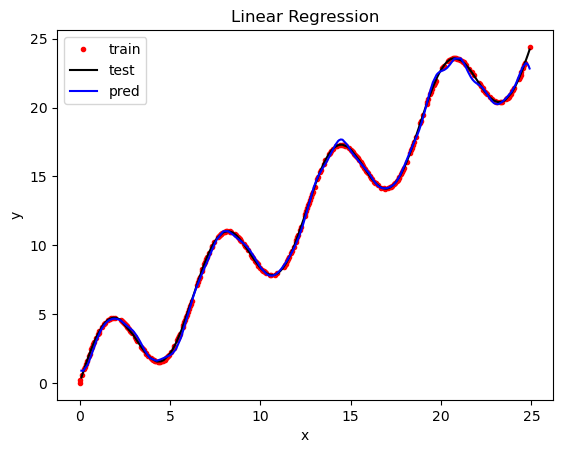

In [56]:
def evaluate(ys, ys_pred):
    """评估模型。"""
    std = np.sqrt(np.mean(np.abs(ys - ys_pred) ** 2))
    return std

# 程序主入口（建议不要改动以下函数的接口）
if __name__ == '__main__':
    train_file = 'train.txt'
    test_file = 'test.txt'
    # 载入数据
    x_train, y_train = load_data(train_file)
    x_test, y_test = load_data(test_file)
    print(x_train.shape)
    print(x_test.shape)

    # 使用线性回归训练模型，返回一个函数f()使得y = f(x)
    f = main(x_train, y_train)

    y_train_pred = f(x_train)
    std = evaluate(y_train, y_train_pred)
    print('训练集预测值与真实值的标准差：{:.1f}'.format(std))
    
    # 计算预测的输出值
    y_test_pred = f(x_test)
    # 使用测试集评估模型
    std = evaluate(y_test, y_test_pred)
    print('预测值与真实值的标准差：{:.1f}'.format(std))

    #显示结果
    plt.plot(x_train, y_train, 'ro', markersize=3)
    plt.plot(x_test, y_test, 'k')
    plt.plot(x_test, y_test_pred, 'b')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title('Linear Regression')
    plt.legend(['train', 'test', 'pred'])
    plt.show()